# Olympic Data Analysis - Exploratory Data Analysis (EDA)

This notebook examines cleaned datasets of Olympic athlete biographies and competition results.

The analysis focuses on athlete characteristics, distributions by country, Olympic participation, and historical medal performance.


## About the Project (Work in Progress)

This study examines the demographic and physical characteristics of athletes in the history of the Olympic Games using exploratory data analysis (EDA) methods. As a Work in Progress (WIP), this initial phase focuses on athlete profiles, including height, weight, age distributions, and overall participation counts by National Olympic Committees (NOCs). 

Currently, the notebook explores the following questions:

* Which NOCs have the highest number of participating athletes?
* How are the physical attributes (height, weight, age) of Olympic athletes distributed?
* What is the correlation between athletes' physical characteristics?
* Who are the youngest and oldest athletes in Olympic history?
* How does the average age of athletes vary across different Olympic Games and seasons?

### Future Work (To-Do List)
The upcoming phases of this project will shift focus from individual athlete demographics to country-level medal performances. Planned analyses include:

- [ ] Which NOCs have the most medal records in Olympic history?
- [ ] How are countries' medal records distributed across sports?
- [ ] How has countries' medal performance changed over time at the Summer Olympics?
- [ ] How has countries' medal performance changed over time at the Winter Olympics?
- [ ] What differences exist between countries' medal distributions at the Summer and Winter Olympics?

*Note: In the analyses, countries are evaluated based on the **NOC codes** in the dataset. Different NOC codes have not been merged, even when they represented the same geographic region or country in different periods. This aims for a consistent comparison based on the codes in the dataset, without any historical grouping.*

## Dataset and Methodology

### Datasets

Two cleaned datasets on Olympic athletes and competition results were used in this study:

* **Athlete biographies (`bios_clean.csv`):** Contains information on athletes' personal and physical characteristics.
* **Competition results (`results_clean.csv`):** Contains records on the Olympic Games, sports, countries, athletes, and medal results.

### Data Cleaning and Preparation

Before the analysis, the datasets were cleaned and the necessary adjustments were made for missing or inconsistent data. The analyses are based on the standard Olympic Games; the Youth Olympic Games were excluded from the scope.

In the medal analyses, records were deduplicated on the basis of event, Games edition, NOC, and medal type, to prevent the same medal type won by the same NOC in the same competition event from being counted more than once.

### Analysis Methods

The following exploratory data analysis methods were applied to the data:

* **Descriptive statistics:** The sizes, variables, and basic distributions of the datasets were examined.
* **Country-level comparisons:** Participation and medal records were analyzed by NOC code.
* **Discipline analysis:** Countries' medal distributions across different sports and their standout disciplines were examined.
* **Period analysis:** Medal performance at the Summer and Winter Olympics was evaluated over 20-year periods.
* **Visualization:** The results of the analysis are presented with comparative charts and tables.

Throughout the analysis, NOC codes used in different periods were not merged. Therefore, the results do not show the uninterrupted historical performance of today's countries, but the records for the NOC codes in the dataset.



In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

bios = pd.read_csv('./bios_clean.csv')
results = pd.read_csv('./results_clean.csv')

In [2]:
print("BIOS shape:", bios.shape)
print("RESULTS shape:", results.shape)

BIOS shape: (145500, 16)
RESULTS shape: (308408, 12)


In [3]:
bios.info()

<class 'pandas.DataFrame'>
RangeIndex: 145500 entries, 0 to 145499
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   roles          145500 non-null  str    
 1   sex            145500 non-null  str    
 2   noc            145499 non-null  str    
 3   athlete_id     145500 non-null  int64  
 4   affiliations   95832 non-null   str    
 5   used_name      145500 non-null  str    
 6   full_name      145500 non-null  str    
 7   height_cm      106651 non-null  float64
 8   weight_min_kg  104210 non-null  float64
 9   weight_max_kg  104210 non-null  float64
 10  birth_date     141685 non-null  str    
 11  birth_year     143698 non-null  float64
 12  birth_place    120926 non-null  str    
 13  birth_country  120926 non-null  str    
 14  died_date      31925 non-null   str    
 15  died_year      33798 non-null   float64
dtypes: float64(5), int64(1), str(10)
memory usage: 17.8 MB


In [4]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 308408 entries, 0 to 308407
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   games       308408 non-null  str    
 1   event       308408 non-null  str    
 2   team        121714 non-null  str    
 3   medal       44139 non-null   str    
 4   as          308408 non-null  str    
 5   athlete_id  308408 non-null  int64  
 6   noc         308408 non-null  str    
 7   discipline  308407 non-null  str    
 8   year        308408 non-null  int64  
 9   season      305807 non-null  str    
 10  pos         279433 non-null  float64
 11  pos_status  27150 non-null   str    
dtypes: float64(1), int64(2), str(9)
memory usage: 28.2 MB


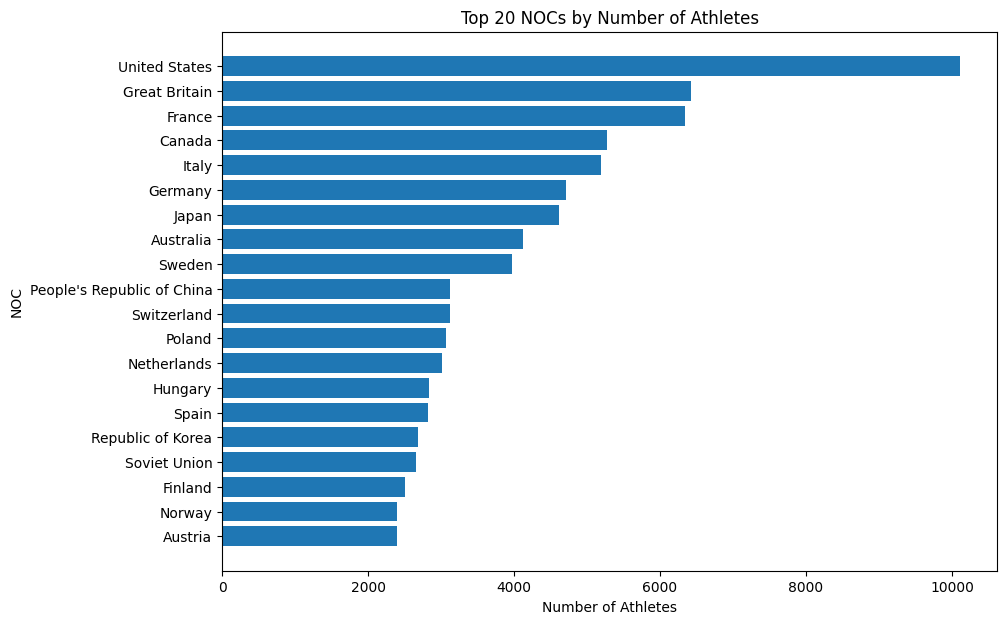

In [5]:
noc_counts = bios['noc'].value_counts().head(20).sort_values()

plt.figure(figsize=(10, 7))
plt.barh(noc_counts.index, noc_counts.values)

plt.title('Top 20 NOCs by Number of Athletes')
plt.xlabel('Number of Athletes')
plt.ylabel('NOC')

plt.show()

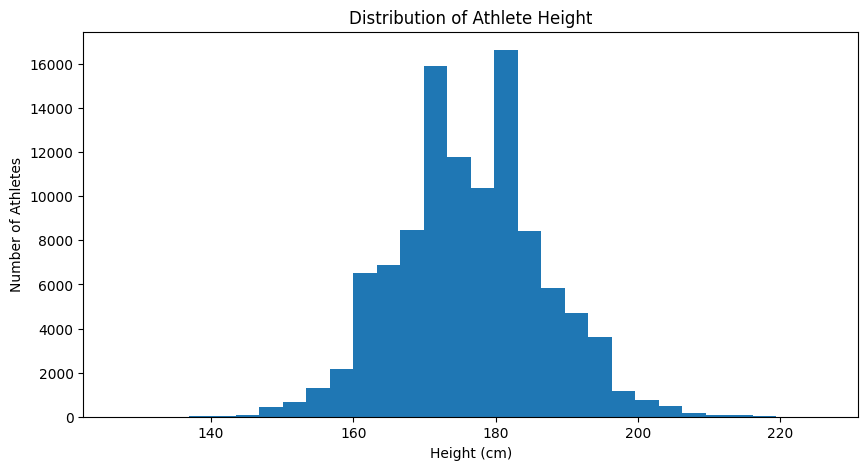

In [6]:
plt.figure(figsize=(10, 5))

plt.hist(
    bios['height_cm'].dropna(),
    bins=30
)

plt.title('Distribution of Athlete Height')
plt.xlabel('Height (cm)')
plt.ylabel('Number of Athletes')

plt.show()

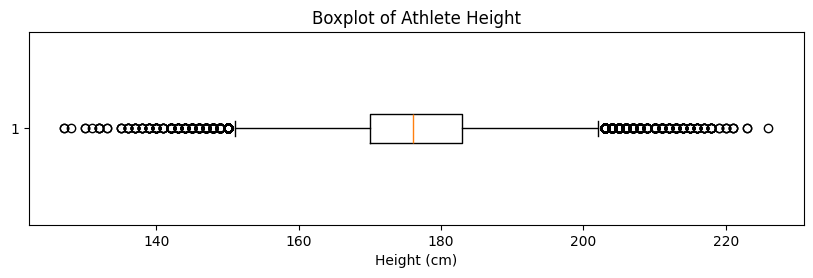

In [7]:
plt.figure(figsize=(10, 2.5))

plt.boxplot(
    bios['height_cm'].dropna(),
    vert=False
)

plt.title('Boxplot of Athlete Height')
plt.xlabel('Height (cm)')

plt.show()

In [8]:
q1 = bios['height_cm'].quantile(0.25)
q3 = bios['height_cm'].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 170.0
Q3: 183.0
IQR: 13.0
Lower bound: 150.5
Upper bound: 202.5


In [9]:
height_outliers = bios[
    (bios['height_cm'] < lower_bound) |
    (bios['height_cm'] > upper_bound)
]

print("Number of outliers:", len(height_outliers))
print("Percentage:", round(len(height_outliers) / bios['height_cm'].notna().sum() * 100, 2))

Number of outliers: 1490
Percentage: 1.4


In [10]:
height_outliers[
    [
        'athlete_id',
        'full_name',
        'used_name',
        'height_cm',
        'birth_year',
        'roles',
        'noc'
    ]
].sort_values('height_cm').head(10)

,athlete_id,full_name,used_name,height_cm,birth_year,roles,noc
28619,28832,Rosario Briones,Rosario Briones,127.0,1953.0,Competed in Olympic Games,Mexico
4515,4530,Lyton Levison Mphande,Lyton Mphande,127.0,1963.0,Competed in Olympic Games,Malawi
4516,4531,Helman Palije,Helman Palije,128.0,1967.0,Competed in Olympic Games,Malawi
4517,4532,Boston Simbeye,Boston Simbeye,130.0,1959.0,Competed in Olympic Games,Malawi
4664,4681,Salvador Miranda,Salvador Miranda,130.0,1949.0,Competed in Olympic Games,Nicaragua
48662,49016,Nadia Fezzani,Nadia Fezzani,131.0,NaN,Competed in Olympic Games,Libya
28105,28315,Ana Olvido Manso Gallego,Ana Manso,132.0,1966.0,Competed in Olympic Games,Spain
43257,43591,Said Mubarak Marhoon Al-Khatry,Said Al-Khatry,132.0,1947.0,Competed in Olympic Games,Oman
43259,43593,Khamis Mohamed Saif Al-Subhi,Khamis Al-Subhi,132.0,1954.0,Competed in Olympic Games,Oman
35826,36109,Michael Conway,Michael Conway,132.0,1953.0,Competed in Olympic Games,Canada


In [11]:
height_outliers[
    [
        'athlete_id',
        'full_name',
        'used_name',
        'height_cm',
        'birth_year',
        'roles',
        'noc'
    ]
].sort_values('height_cm', ascending=False).head(10)

,athlete_id,full_name,used_name,height_cm,birth_year,roles,noc
89070,89782,Yao Ming,Yao Ming,226.0,1980.0,Competed in Olympic Games • Other,People's Republic of China
5781,5804,"Thomas Loren ""Tommy"" Burleson",Tommy Burleson,223.0,1952.0,Competed in Olympic Games,United States
6978,7013,Arvydas Romas Sabonis,Arvydas Sabonis,223.0,1964.0,Competed in Olympic Games,Lithuania Soviet Union
5673,5696,Gunther Behnke,Gunther Behnke,221.0,1963.0,Competed in Olympic Games,Germany
89075,89787,Roberto Dueñas Hernández,Roberto Dueñas,221.0,1975.0,Competed in Olympic Games,Spain
120266,122147,Zhang Zhaoxu,Zhang Zhaoxu,221.0,1987.0,Competed in Olympic Games,People's Republic of China
7188,7226,Vladimir Petrovich Tkachenko,Vladimir Tkachenko,220.0,1957.0,Competed in Olympic Games,Soviet Union
6504,6537,"Lucien James ""Luc"" Longley",Luc Longley,220.0,1969.0,Competed in Olympic Games,Australia
5089,5108,Viktor Aleksandrovich Pankrashkin,Viktor Pankrashkin,220.0,1957.0,Competed in Olympic Games,Soviet Union
107408,108533,Peter John Ramos Fuentes,Peter John Ramos,219.0,1985.0,Competed in Olympic Games,Puerto Rico


#### 📌 Çıkarım: Boy Dağılımı ve Uç Noktalar
Sporcuların boy dağılımı incelendiğinde, verinin genel olarak normal dağılım eğilimi gösterdiği (medyan: 175 cm), ancak her iki uçta da istatistiksel aykırı değerler (outliers) barındırdığı tespit edilmiştir. Kutu grafiği (boxplot) kullanılarak yapılan IQR analizinde, boy verisi olan sporcuların yaklaşık **%1.4'ünün (1490 kişi)** standart sınırların dışında kaldığı görülmüştür.

Sayısal verilere bakıldığında:
*   **En kısa sporcular:** 127 cm boyuyla Meksikalı Rosario Briones ve Malavili Lyton Levison Mphande gibi isimlerdir. (Genellikle jimnastik, dalış vb. sporlar)
*   **En uzun sporcular:** 226 cm ile Çinli Yao Ming ve 223 cm ile Tommy Burleson gibi basketbol oyuncularıdır.

Bu durum, Olimpiyatların jimnastikten basketbola kadar çok farklı fiziksel avantajlar ve gereksinimler isteyen spor branşlarını bir arada barındırmasından kaynaklanmaktadır.

In [12]:
bios[['weight_min_kg', 'weight_max_kg']].describe()

,weight_min_kg,weight_max_kg
count,104210.000000,104210.000000
mean,71.953474,72.007298
std,14.547167,14.594882
min,25.000000,25.000000
25%,62.000000,62.000000
50%,70.000000,71.000000
75%,80.000000,80.000000
max,210.000000,218.000000


In [13]:
print("Weight min missing:", bios['weight_min_kg'].isna().sum())
print("Weight max missing:", bios['weight_max_kg'].isna().sum())

Weight min missing: 41290
Weight max missing: 41290


In [14]:
weight_range = bios[
    bios['weight_min_kg'].notna() &
    bios['weight_max_kg'].notna() &
    (bios['weight_min_kg'] != bios['weight_max_kg'])
]

print("Weight ranges:", len(weight_range))
print(
    "Percentage:",
    round(
        len(weight_range) / bios['weight_min_kg'].notna().sum() * 100,
        2
    )
)

Weight ranges: 1028
Percentage: 0.99


In [15]:
weight_range['weight_max_kg'].sub(
    weight_range['weight_min_kg']
).describe()

count    1028.000000
mean        5.456226
std         5.341778
min         1.000000
25%         2.000000
50%         4.000000
75%         7.000000
max        60.000000
dtype: float64

In [16]:
bios['weight_mid_kg'] = (
    bios['weight_min_kg'] + bios['weight_max_kg']
) / 2

In [17]:
bios['weight_mid_kg'].describe()

count    104210.000000
mean         71.980386
std          14.566136
min          25.000000
25%          62.000000
50%          71.000000
75%          80.000000
max         214.000000
Name: weight_mid_kg, dtype: float64

In [18]:
bios['weight_mid_kg'].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

0.01     45.0
0.05     51.0
0.25     62.0
0.50     71.0
0.75     80.0
0.95     97.0
0.99    115.0
Name: weight_mid_kg, dtype: float64

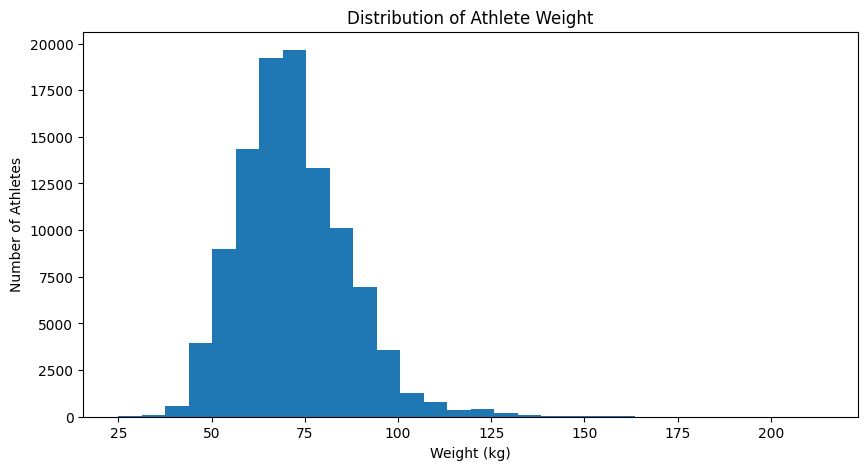

In [19]:
plt.figure(figsize=(10, 5))

plt.hist(
    bios['weight_mid_kg'].dropna(),
    bins=30
)

plt.title('Distribution of Athlete Weight')
plt.xlabel('Weight (kg)')
plt.ylabel('Number of Athletes')

plt.show()

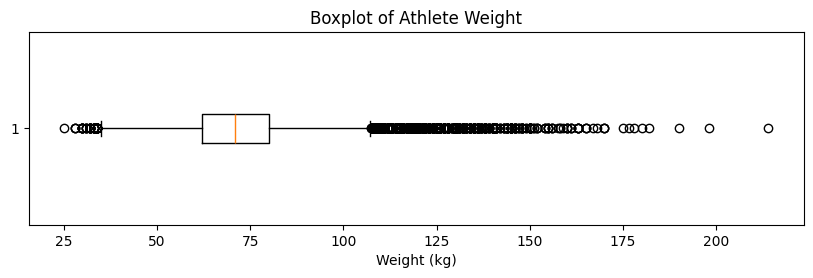

In [20]:
plt.figure(figsize=(10, 2.5))

plt.boxplot(
    bios['weight_mid_kg'].dropna(),
    vert=False
)

plt.title('Boxplot of Athlete Weight')
plt.xlabel('Weight (kg)')

plt.show()

In [21]:
bios.loc[
    bios['weight_mid_kg'].nsmallest(15).index,
    ['used_name', 'weight_min_kg', 'weight_max_kg', 'weight_mid_kg']
]

,used_name,weight_min_kg,weight_max_kg,weight_mid_kg
28762,Choi Myong-Hui,25.0,25.0,25.0
28712,Anita Jokiel,28.0,28.0,28.0
90795,Kana Yamawaki,28.0,28.0,28.0
114713,Wang Xin,28.0,28.0,28.0
28042,Lu Li,30.0,30.0,30.0
28159,Céline Degrange,30.0,30.0,30.0
28760,Choe Jong-Sil,30.0,30.0,30.0
28958,Liubov Sheremeta,30.0,30.0,30.0
28968,Mariya Filatova,30.0,30.0,30.0
90572,Sara Moro,30.0,30.0,30.0


In [22]:
bios.loc[
    bios['weight_mid_kg'].nlargest(15).index,
    ['used_name', 'weight_min_kg', 'weight_max_kg', 'weight_mid_kg']
]

,used_name,weight_min_kg,weight_max_kg,weight_mid_kg
111496,"Ricardo Blas, Jr.",210.0,218.0,214.0
105715,Aythami Ruano,198.0,198.0,198.0
59204,Marek Galiński,190.0,190.0,190.0
60344,Chris Taylor,182.0,182.0,182.0
91712,Valentyn Rusliakov,180.0,180.0,180.0
105722,Leonel Wilfredo Ruiz,178.0,178.0,178.0
56581,Mark Henry,166.0,187.0,176.5
105671,Dmitry Nosov,175.0,175.0,175.0
56240,Andrey Chemerkin,165.0,175.0,170.0
111533,Janusz Wojnarowicz,170.0,170.0,170.0


📌 Çıkarım: Kilo Dağılımı ve Genç Sporcu Etkisi
Boyda olduğu gibi kiloda da büyük bir çeşitlilik mevcuttur. Sporcuların ortalama kilosu ~72 kg, medyan kilosu ise 71 kg'dır. Katılımcıların %50'si (IQR) 62 kg ile 80 kg arasında yer almaktadır.

Sayısal verilere bakıldığında olimpiyat tarihinin ekstrem sınırlarını net bir şekilde görebiliyoruz:

En hafif sporcular: Sadece 25 kg ağırlığıyla Choi Myong-Hui ve 28 kg ile Anita Jokiel gibi isimler öne çıkmaktadır. İlk bakışta bu durumun Gençlik Olimpiyatları'ndan kaynaklandığı düşünülebilse de, veriler bu sporcuların 1980 Yaz Olimpiyatları'nda henüz 14 yaşındayken (Artistik Jimnastik branşında) yarıştıklarını göstermektedir. Yaş sınırlamalarının daha esnek olduğu dönemlerde jimnastik ve atlama gibi branşlardaki genç yaş/düşük kilo avantajı bu ekstrem uçları oluşturmaktadır.

En ağır sporcular: 214 kg ağırlığıyla Ricardo Blas Jr. ve 198 kg ile Aythami Ruano gibi ağır sıklet güreş/judo sporcuları veri setindeki en ağır kişilerdir.

In [23]:
height_weight = bios[
    bios['height_cm'].notna() &
    bios['weight_mid_kg'].notna()
]

print("Height + weight available:", len(height_weight))

Height + weight available: 103028


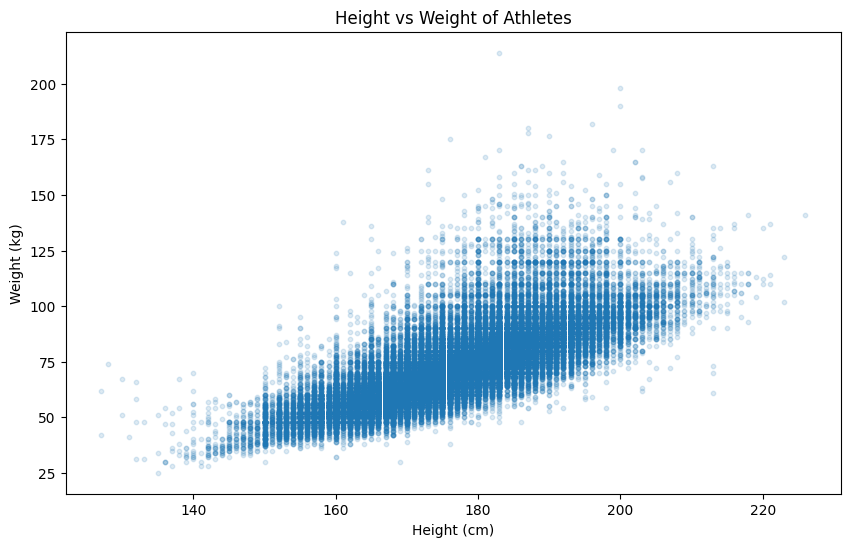

In [24]:
plt.figure(figsize=(10, 6))

plt.scatter(
    height_weight['height_cm'],
    height_weight['weight_mid_kg'],
    alpha=0.15,
    s=10
)

plt.title('Height vs Weight of Athletes')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')

plt.show()

In [25]:
correlation = height_weight['height_cm'].corr(
    height_weight['weight_mid_kg']
)

print("Height-Weight Correlation:", correlation)

Height-Weight Correlation: 0.7758535736186213


#### 📌 Çıkarım: Boy ve Kilo İlişkisi (Korelasyon Analizi)
Sporcuların boy ve kiloları arasındaki ilişki saçılım grafiği (scatter plot) ile incelendiğinde, değişkenler arasında pozitif yönlü, doğrusal bir eğilim olduğu görsel olarak fark edilmektedir. 

Hesaplanan Pearson korelasyon katsayısı **0.7758**'dir. Bu değer, boy ve kilo arasında **istatistiksel olarak oldukça güçlü ve pozitif bir doğrusal ilişki** olduğunu kanıtlamaktadır. Beklendiği üzere, olimpiyat seviyesindeki sporcuların boyları arttıkça kiloları da tutarlı bir şekilde artmaktadır.

In [26]:
age_data = results.merge(
    bios[['athlete_id', 'birth_year']],
    on='athlete_id',
    how='left'
)

age_data['age'] = age_data['year'] - age_data['birth_year']

In [27]:
print("Results:", len(results))
print("Age data:", len(age_data))

print("\nMissing birth year:")
print(age_data['birth_year'].isna().sum())

print("\nMissing age:")
print(age_data['age'].isna().sum())

Results: 308408
Age data: 308408

Missing birth year:
2709

Missing age:
2709


In [28]:
age_data['age'].describe()

count    305699.000000
mean         25.712649
std           5.946249
min          11.000000
25%          22.000000
50%          25.000000
75%          29.000000
max          73.000000
Name: age, dtype: float64

In [29]:
age_data['age'].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

0.01    16.0
0.05    18.0
0.25    22.0
0.50    25.0
0.75    29.0
0.95    36.0
0.99    45.0
Name: age, dtype: float64

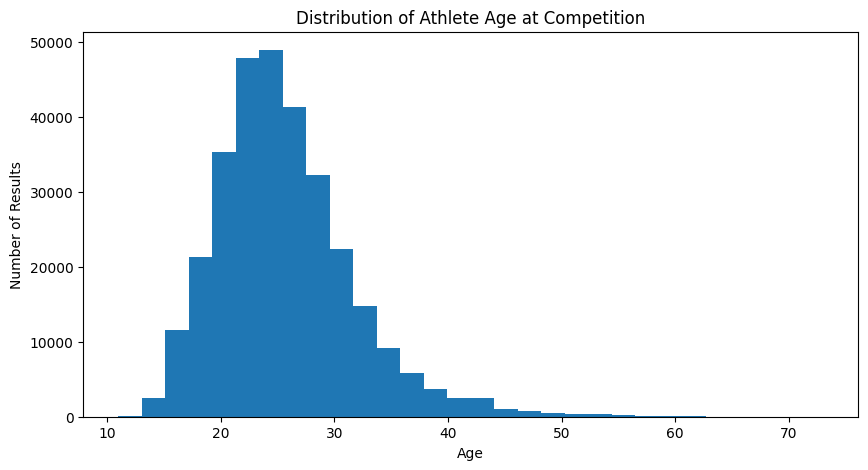

In [30]:
plt.figure(figsize=(10, 5))

plt.hist(
    age_data['age'].dropna(),
    bins=30
)

plt.title('Distribution of Athlete Age at Competition')
plt.xlabel('Age')
plt.ylabel('Number of Results')

plt.show()

In [31]:
age_data.loc[
    age_data['age'].nsmallest(15).index,
    ['athlete_id', 'birth_year', 'year', 'age']
]

,athlete_id,birth_year,year,age
64165,30338,1885.0,1896,11.0
305214,146782,2009.0,2020,11.0
54407,28707,1916.0,1928,12.0
54571,28750,1916.0,1928,12.0
79257,35583,1960.0,1972,12.0
80813,36692,1980.0,1992,12.0
100218,46308,1924.0,1936,12.0
105213,48112,1980.0,1992,12.0
105214,48112,1980.0,1992,12.0
105778,48275,1940.0,1952,12.0


In [32]:
age_data.loc[
    age_data['age'].nlargest(15).index,
    ['athlete_id', 'birth_year', 'year', 'age']
]

,athlete_id,birth_year,year,age
94807,44288,1847.0,1920,73.0
94808,44288,1847.0,1920,73.0
94809,44288,1847.0,1920,73.0
23048,12965,1864.0,1936,72.0
23049,12965,1864.0,1936,72.0
131957,62914,1828.0,1900,72.0
131958,62914,1828.0,1900,72.0
131959,62914,1828.0,1900,72.0
131960,62914,1828.0,1900,72.0
131961,62914,1828.0,1900,72.0


#### 📌 Çıkarım: Olimpiyatlarda Yaş Dağılımı
Hesaplanan `age` değişkeni analiz edildiğinde, olimpiyatlara katılan sporcuların **yaş ortalamasının 25.7, medyan yaşın ise 25** olduğu görülmektedir. Verilerin büyük çoğunluğu (%50'lik dilim) 22 ile 29 yaşları arasındadır.

Ancak minimum ve maksimum değerler Olimpiyatların her yaş grubuna hitap edebilen yapısını ortaya koymaktadır:
*   Tarihteki **en genç** katılımcıların **11 yaşında** olduğu görülmektedir (Örn: 1896 Atina'da Dimitrios Loundras veya 2020 Tokyo'da kaykay/masa tenisi gibi branşlardaki genç sporcular).
*   Tarihteki **en yaşlı** katılımcılar ise **73 yaşına** kadar ulaşabilmektedir. (Bu durum özellikle binicilik, atıcılık veya eski dönemlerdeki sanat yarışmaları gibi fiziksel kondisyondan çok teknik ve deneyimin öne çıktığı branşlarda görülmektedir.)

In [33]:
age_olympics = age_data[
    ~age_data['games'].str.contains('Youth Olympics', na=False) &
    age_data['season'].isin(['Summer', 'Winter'])
].copy()

print("Original records:", len(age_data))
print("Regular Olympic records:", len(age_olympics))

Original records: 308408
Regular Olympic records: 299732


In [34]:
age_olympics_by_year = (
    age_olympics
    .dropna(subset=['age'])
    .groupby(['year', 'season'])['age']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

age_olympics_by_year.head(10)

,year,season,mean,median,count
0,1896,Summer,24.226782,24.0,463
1,1900,Summer,28.767742,26.0,1860
2,1904,Summer,26.861714,25.0,1750
3,1908,Summer,27.348571,25.0,3500
4,1912,Summer,27.678608,26.0,4857
5,1920,Summer,29.919519,28.0,4237
6,1924,Summer,28.121969,26.0,5526
7,1924,Winter,28.027223,27.0,551
8,1928,Summer,26.392744,25.0,4438
9,1928,Winter,27.385878,26.0,609


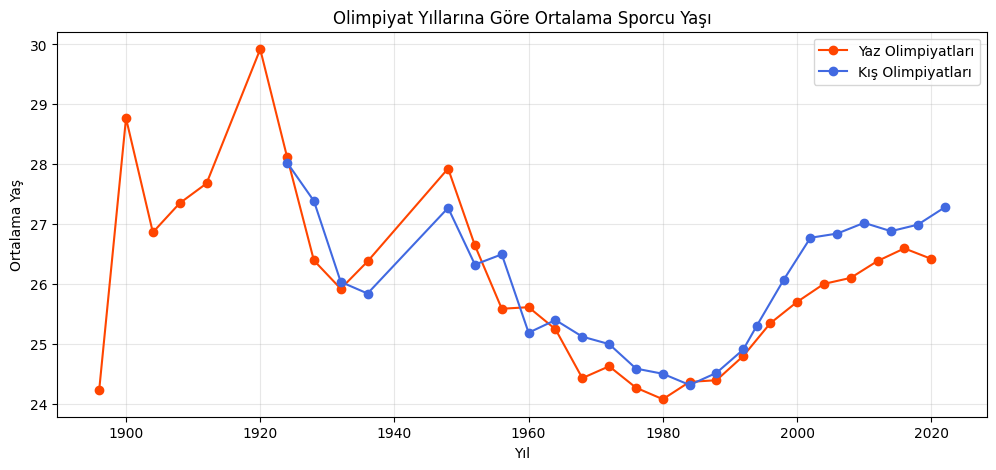

In [70]:
plt.figure(figsize=(12, 5))

season_colors = {
    'Summer': 'orangered',
    'Winter': 'royalblue'
}

for season in ['Summer', 'Winter']:
    data = age_olympics_by_year[
        age_olympics_by_year['season'] == season
    ]

    plt.plot(
        data['year'],
        data['mean'],
        marker='o',
        label=season,
        color=season_colors[season]
    )

plt.title('Olimpiyat Yıllarına Göre Ortalama Sporcu Yaşı')
plt.xlabel('Yıl')
plt.ylabel('Ortalama Yaş')
plt.legend(
    labels=['Yaz Olimpiyatları', 'Kış Olimpiyatları']
)
plt.grid(alpha=0.3)

plt.show()

#### 📌 Çıkarım: Sezonlara ve Yıllara Göre Yaş Trendi
Gençlik Olimpiyatları (Youth Olympics) veri setinden çıkarılarak sadece standart olimpiyatlara bakıldığında, yaş ortalamasının yıllara ve Yaz/Kış sezonlarına göre değişimi incelenmiştir.

Grafik incelendiğinde öne çıkan tarihsel trendler şunlardır:
* **İlk Yıllar ve Dalgalanmalar:** Olimpiyatların başladığı 1896 yılında yaş ortalaması 24.2 iken, 1900'de 28.7'ye sıçramış ve 1920'lerde 28-29 bandına yerleşmiştir. 
* **1980'lere Kadar Düşüş:** 1920'lerden 1980'lere kadar olimpiyat sporcularının yaş ortalamasında istikrarlı bir düşüş yaşanmış ve ortalama 24 yaş seviyelerine kadar inmiştir. Bu durum, sporun daha profesyonel hale gelmesi ve genç yeteneklerin daha erken yaşta keşfedilmesiyle açıklanabilir.
* **Modern Dönemde Yeniden Yükseliş ve Kış Olimpiyatları Farkı:** 1980'lerden günümüze kadar yaş ortalaması tekrar yükselişe geçerek 26-27 bandına oturmuştur. Ayrıca modern dönemde, Kış Olimpiyatları'na katılan sporcuların yaş ortalamasının Yaz Olimpiyatları'na göre belirgin bir şekilde daha yüksek olduğu dikkat çekmektedir.

In [36]:
athletes_by_noc = (
    bios
    .groupby('noc')['athlete_id']
    .nunique()
    .sort_values(ascending=False)
)

athletes_by_noc.head(20)

noc
United States                 10114
Great Britain                  6421
France                         6339
Canada                         5276
Italy                          5189
Germany                        4714
Japan                          4609
Australia                      4125
Sweden                         3972
People's Republic of China     3128
Switzerland                    3127
Poland                         3064
Netherlands                    3011
Hungary                        2835
Spain                          2825
Republic of Korea              2689
Soviet Union                   2654
Finland                        2510
Norway                         2399
Austria                        2399
Name: athlete_id, dtype: int64

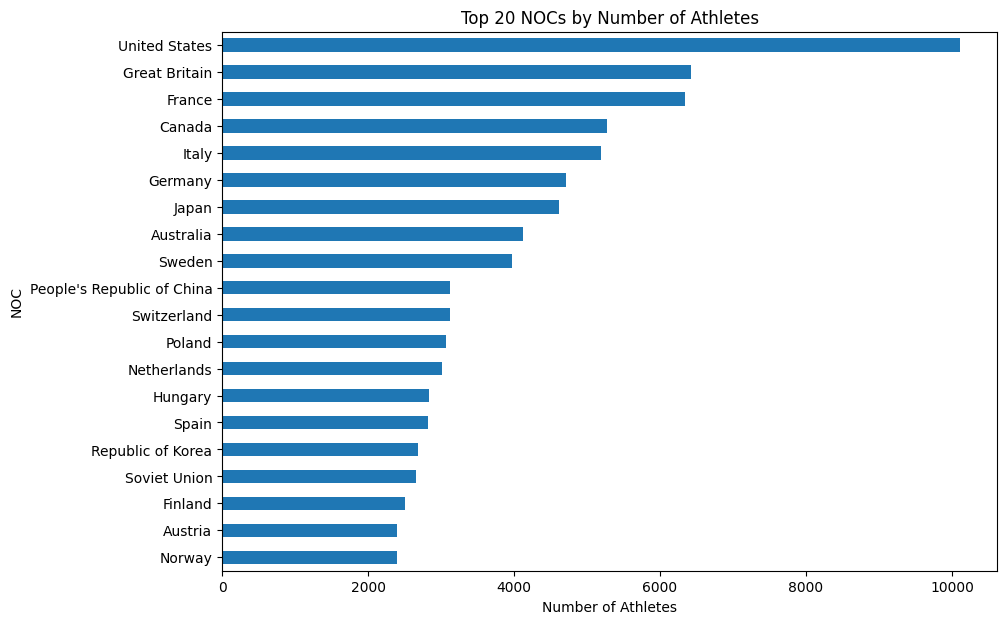

In [37]:
plt.figure(figsize=(10, 7))

athletes_by_noc.head(20).sort_values().plot(
    kind='barh'
)

plt.title('Top 20 NOCs by Number of Athletes')
plt.xlabel('Number of Athletes')
plt.ylabel('NOC')

plt.show()

In [38]:
medal_events = (
    results[
        results['medal'].notna()
    ]
    .drop_duplicates(['games', 'event', 'noc', 'medal'])
)

medal_events.shape

(21075, 12)

In [39]:
medals_by_noc = (
    medal_events
    .groupby(['noc', 'medal'])
    .size()
    .unstack(fill_value=0)
)

medals_by_noc['Total'] = medals_by_noc.sum(axis=1)

medals_by_noc.sort_values('Total', ascending=False).head(20)

medal,Bronze,Gold,Silver,Total
noc,,,,
USA,842,1182,957,2981
URS,348,466,367,1181
GER,366,345,376,1087
GBR,337,308,338,983
FRA,358,289,311,958
ITA,277,274,246,797
CHN,199,301,235,735
SWE,248,215,228,691
RUS,203,229,199,631


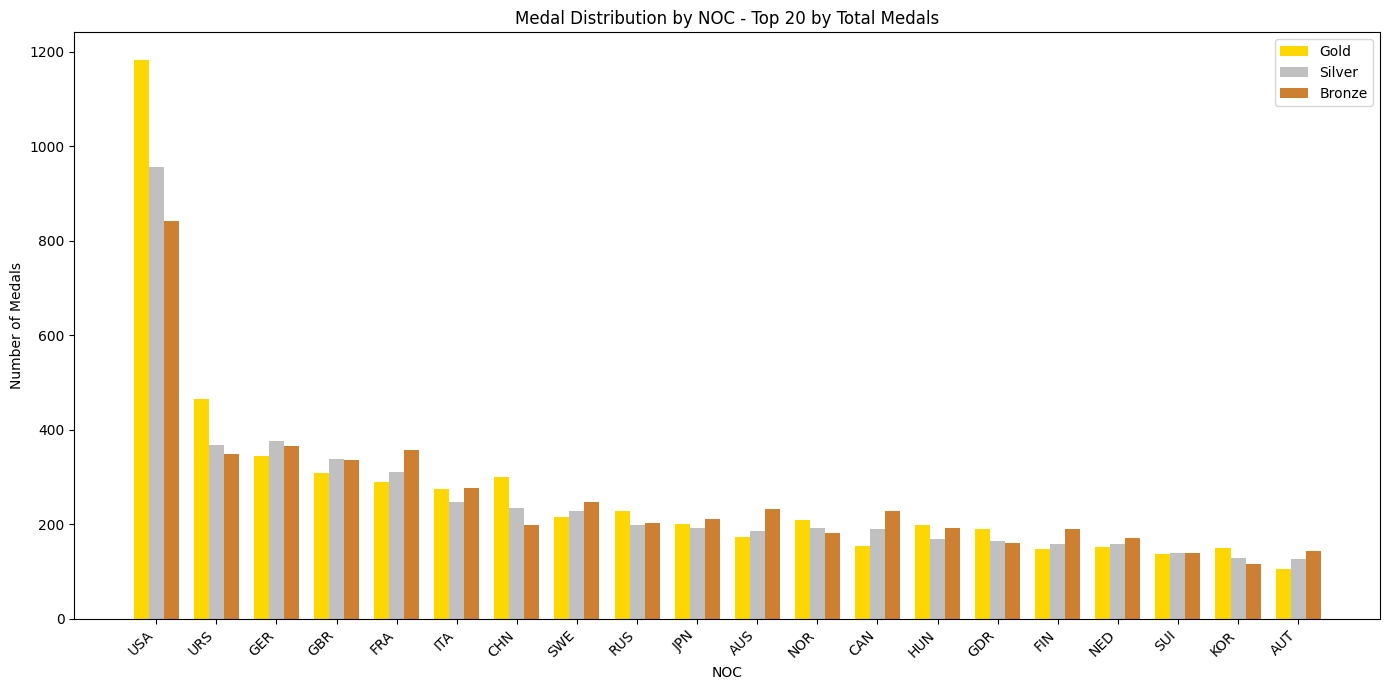

In [40]:
plt.figure(figsize=(14, 7))

top_20 = medals_by_noc.sort_values('Total', ascending=False).head(20)

x = range(len(top_20))
width = 0.25

plt.bar(
    [i - width for i in x],
    top_20['Gold'],
    width=width,
    label='Gold',
    color='gold'
)

plt.bar(
    x,
    top_20['Silver'],
    width=width,
    label='Silver',
    color='silver'
)

plt.bar(
    [i + width for i in x],
    top_20['Bronze'],
    width=width,
    label='Bronze',
    color='#CD7F32'
)

plt.xticks(x, top_20.index, rotation=45, ha='right')
plt.xlabel('NOC')
plt.ylabel('Number of Medals')
plt.title('Medal Distribution by NOC - Top 20 by Total Medals')
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
medal_events_olympics = (
    results[
        ~results['games'].str.contains('Youth Olympics', na=False) &
        results['season'].isin(['Summer', 'Winter']) &
        results['medal'].notna()
    ]
    .drop_duplicates(['games', 'event', 'noc', 'medal'])
)

In [42]:
medals_by_year_season = (
    medal_events_olympics
    .groupby(['year', 'season'])
    .size()
    .reset_index(name='medal_count')
)

medals_by_year_season.head(15)

,year,season,medal_count
0,1896,Summer,121
1,1900,Summer,279
2,1904,Summer,273
3,1908,Summer,311
4,1912,Summer,304
5,1920,Summer,427
6,1924,Summer,376
7,1924,Winter,49
8,1928,Summer,324
9,1928,Winter,41


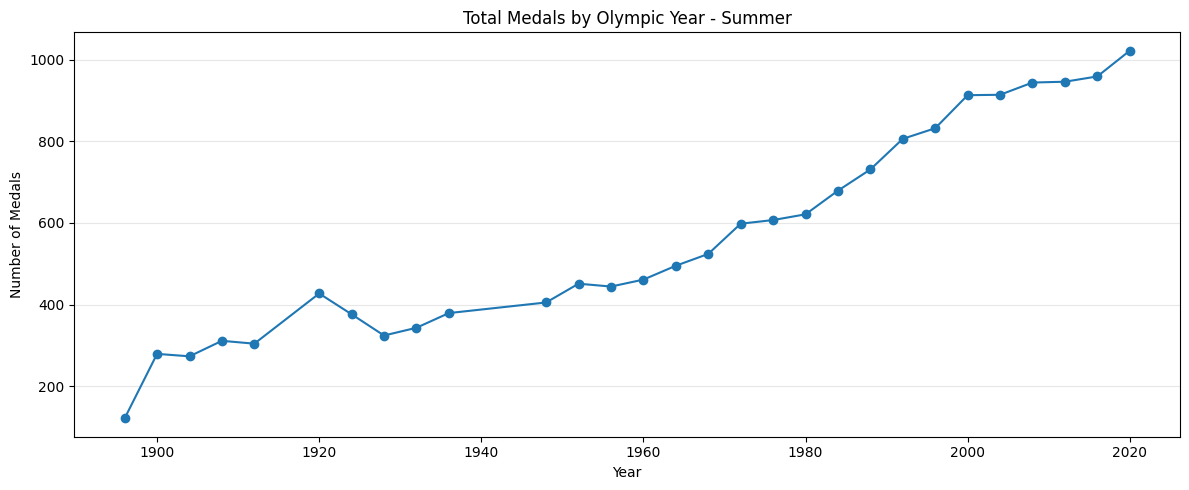

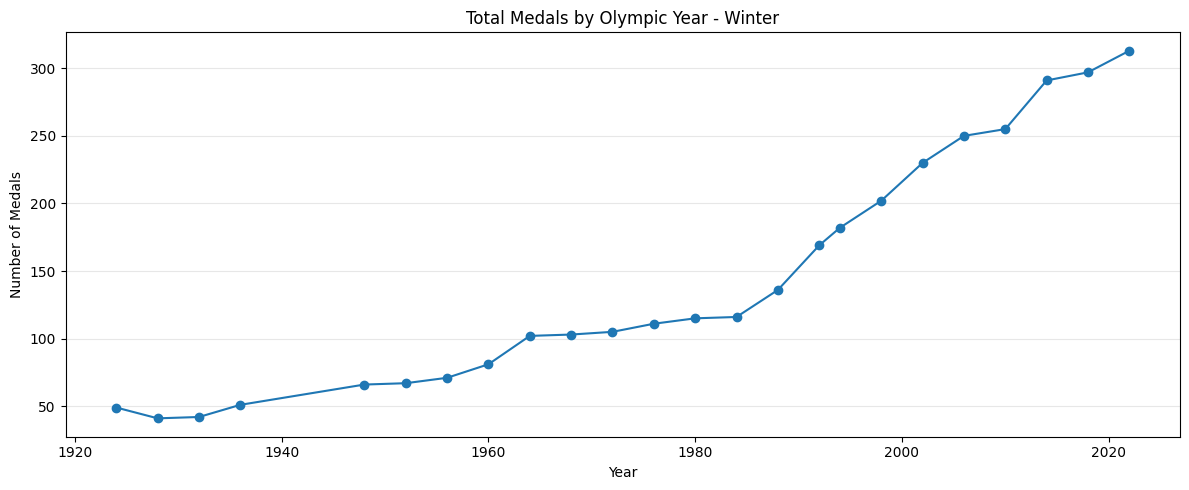

In [43]:
for season in ['Summer', 'Winter']:
    data = medals_by_year_season[
        medals_by_year_season['season'] == season
    ]

    plt.figure(figsize=(12, 5))

    plt.plot(
        data['year'],
        data['medal_count'],
        marker='o'
    )

    plt.title(f'Total Medals by Olympic Year - {season}')
    plt.xlabel('Year')
    plt.ylabel('Number of Medals')
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [44]:
noc_history = (
    medal_events_olympics
    .groupby('noc')
    .agg(
        first_year=('year', 'min'),
        last_year=('year', 'max'),
        olympic_count=('games', 'nunique'),
        medal_count=('medal', 'count'),
        seasons=('season', 'nunique')
    )
    .sort_values(['first_year', 'last_year'])
    .reset_index()
)

noc_history

,noc,first_year,last_year,olympic_count,medal_count,seasons
0,DEN,1896,2020,29,206,2
1,GRE,1896,2020,20,119,1
2,AUS,1896,2022,34,559,2
3,AUT,1896,2022,49,341,2
4,FRA,1896,2022,51,883,2
...,...,...,...,...,...,...
147,KOS,2016,2020,2,3,1
148,ROC,2018,2022,3,113,2
149,BUR,2020,2020,1,1,1
150,SMR,2020,2020,1,3,1


In [45]:
noc_history[
    (noc_history['olympic_count'] <= 5) |
    (noc_history['last_year'] < 2000)
].sort_values('first_year')

,noc,first_year,last_year,olympic_count,medal_count,seasons
10,BOH,1900,1908,2,5,1
21,ANZ,1908,1912,2,12,1
25,LUX,1920,1992,3,4,2
26,TCH,1920,1992,27,168,2
31,HAI,1924,1928,2,2,1
...,...,...,...,...,...,...
147,KOS,2016,2020,2,3,1
148,ROC,2018,2022,3,113,2
149,BUR,2020,2020,1,1,1
150,SMR,2020,2020,1,3,1


In [46]:
noc_medal_summary = (
    medal_events_olympics
    .groupby('noc')
    .agg(
        medal_count=('medal', 'count'),
        first_year=('year', 'min'),
        last_year=('year', 'max'),
        olympic_count=('games', 'nunique')
    )
    .sort_values('medal_count', ascending=False)
    .reset_index()
)

noc_medal_summary.head(15)

,noc,medal_count,first_year,last_year,olympic_count
0,USA,2925,1896,2022,52
1,URS,1181,1952,1988,18
2,GER,1027,1896,2022,36
3,GBR,937,1896,2022,46
4,FRA,883,1896,2022,51
5,ITA,748,1900,2022,47
6,CHN,674,1984,2022,19
7,SWE,651,1900,2022,51
8,JPN,562,1920,2022,36
9,NOR,560,1900,2022,48


In [47]:
# Participation records for the regular Olympic Games
participation = results[
    ~results['games'].str.contains('Youth Olympics', na=False) &
    results['season'].isin(['Summer', 'Winter'])
].copy()

# Unique Olympic appearances per NOC
appearances = (
    participation[['noc', 'games']]
    .drop_duplicates()
    .groupby('noc')
    .size()
    .reset_index(name='appearances')
)

# Medal count per NOC
medals = (
    medal_events_olympics
    .groupby('noc')
    .size()
    .reset_index(name='medal_count')
)

# Merge appearance and medal counts
medal_per_appearance = (
    appearances
    .merge(medals, on='noc', how='left')
    .fillna({'medal_count': 0})
)

medal_per_appearance['medals_per_appearance'] = (
    medal_per_appearance['medal_count'] /
    medal_per_appearance['appearances']
)

medal_per_appearance = (
    medal_per_appearance
    .sort_values('medals_per_appearance', ascending=False)
    .reset_index(drop=True)
)

medal_per_appearance.head(15)

,noc,appearances,medal_count,medals_per_appearance
0,EUN,2,134.0,67.000000
1,URS,18,1181.0,65.611111
2,USA,52,2925.0,56.250000
3,GDR,11,515.0,46.818182
4,ROC,3,113.0,37.666667
5,RUS,16,546.0,34.125000
6,GER,36,1027.0,28.527778
7,CHN,26,674.0,25.923077
8,FRG,11,238.0,21.636364
9,GBR,53,937.0,17.679245


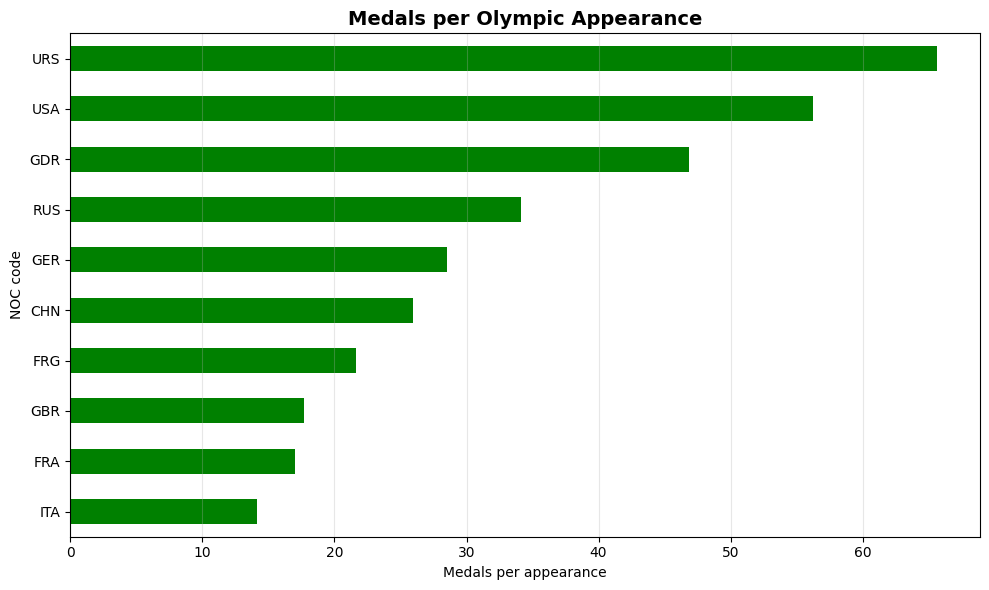

In [67]:
# NOCs with at least 10 Olympic appearances
reliable_noc = medal_per_appearance[
    medal_per_appearance['appearances'] >= 10
]

top_efficiency = reliable_noc.nlargest(
    10, 'medals_per_appearance'
).sort_values('medals_per_appearance')

ax = top_efficiency.plot(
    x='noc',
    y='medals_per_appearance',
    kind='barh',
    figsize=(10, 6),
    legend=False,
    color='green'
)

ax.set_title(
    'Medals per Olympic Appearance',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Medals per appearance')
ax.set_ylabel('NOC code')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
# Number of Summer Olympics appearances
summer_appearances = (
    participation[participation['season'] == 'Summer']
    [['noc', 'games']]
    .drop_duplicates()
    .groupby('noc')
    .size()
    .reset_index(name='appearances')
)

# Medal records won at the Summer Olympics
summer_medals = (
    medal_events_olympics[medal_events_olympics['season'] == 'Summer']
    .groupby('noc')
    .size()
    .reset_index(name='medal_count')
)

# Merge appearance and medal counts
summer_performance = summer_appearances.merge(
    summer_medals,
    on='noc',
    how='left'
).fillna({'medal_count': 0})

summer_performance['medals_per_appearance'] = (
    summer_performance['medal_count'] /
    summer_performance['appearances']
)

# NOCs with at least 8 appearances
summer_performance_filtered = (
    summer_performance[
        summer_performance['appearances'] >= 8
    ]
    .sort_values('medals_per_appearance', ascending=False)
    .reset_index(drop=True)
)

summer_performance_filtered.head(15)

,noc,appearances,medal_count,medals_per_appearance
0,URS,9,990.0,110.000000
1,USA,28,2611.0,93.250000
2,CHN,14,598.0,42.714286
3,RUS,10,426.0,42.600000
4,GER,20,744.0,37.200000
5,GBR,29,903.0,31.137931
6,FRA,28,745.0,26.607143
7,JPN,23,487.0,21.173913
8,ITA,29,610.0,21.034483
9,AUS,27,540.0,20.000000


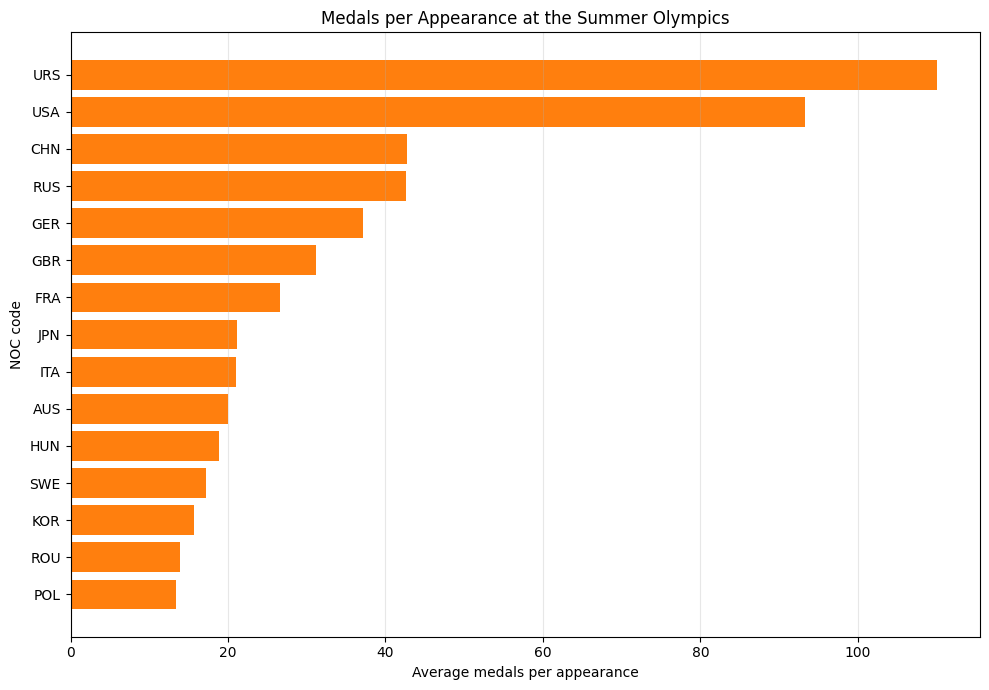

In [50]:
top_summer = (
    summer_performance_filtered
    .head(15)
    .sort_values('medals_per_appearance')
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_summer['noc'],
    top_summer['medals_per_appearance'],
    color='#ff7f0e'
)

plt.xlabel('Average medals per appearance')
plt.ylabel('NOC code')
plt.title('Medals per Appearance at the Summer Olympics')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
# Number of Winter Olympics appearances
winter_appearances = (
    participation[participation['season'] == 'Winter']
    [['noc', 'games']]
    .drop_duplicates()
    .groupby('noc')
    .size()
    .reset_index(name='appearances')
)

# Medal records won at the Winter Olympics
winter_medals = (
    medal_events_olympics[medal_events_olympics['season'] == 'Winter']
    .groupby('noc')
    .size()
    .reset_index(name='medal_count')
)

# Merge appearance and medal counts
winter_performance = winter_appearances.merge(
    winter_medals,
    on='noc',
    how='left'
).fillna({'medal_count': 0})

winter_performance['medals_per_appearance'] = (
    winter_performance['medal_count'] /
    winter_performance['appearances']
)

# NOCs with at least 8 Winter Olympics appearances
winter_performance_filtered = (
    winter_performance[
        winter_performance['appearances'] >= 8
    ]
    .sort_values('medals_per_appearance', ascending=False)
    .reset_index(drop=True)
)

winter_performance_filtered.head(15)

,noc,appearances,medal_count,medals_per_appearance
0,URS,9,191.0,21.222222
1,GER,16,283.0,17.687500
2,NOR,24,402.0,16.750000
3,USA,24,314.0,13.083333
4,AUT,24,249.0,10.375000
5,CAN,24,221.0,9.208333
6,FIN,24,175.0,7.291667
7,SWE,24,170.0,7.083333
8,SUI,24,166.0,6.916667
9,NED,22,143.0,6.500000


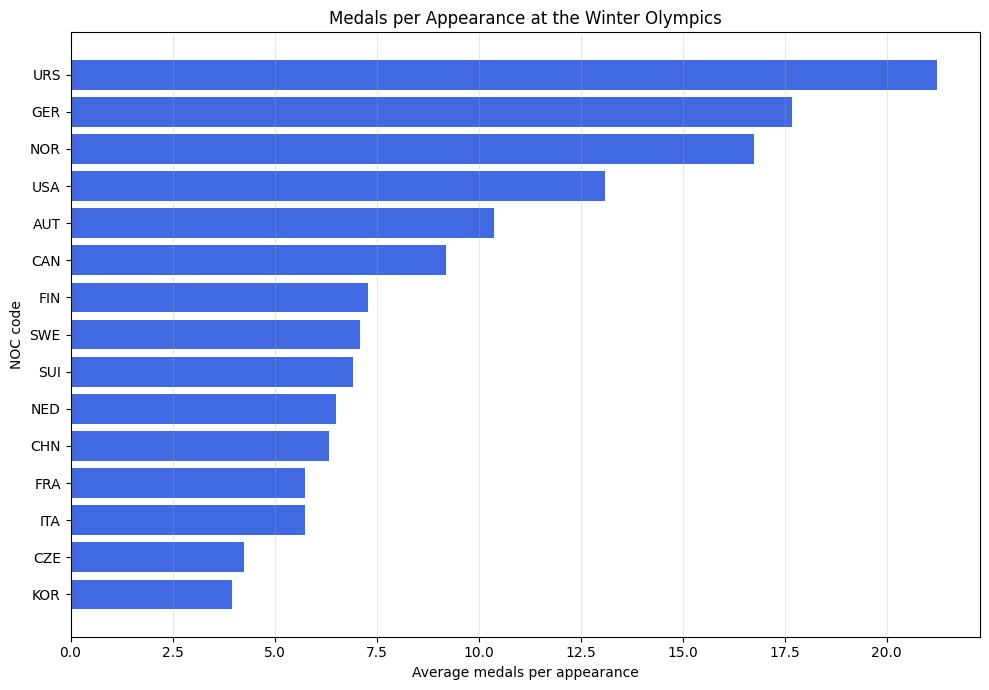

In [66]:
top_winter = (
    winter_performance_filtered
    .head(15)
    .sort_values('medals_per_appearance')
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_winter['noc'],
    top_winter['medals_per_appearance'],
    color='royalblue'
)

plt.xlabel('Average medals per appearance')
plt.ylabel('NOC code')
plt.title('Medals per Appearance at the Winter Olympics')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
# Participation by country at the Summer Olympics
summer_participation = (
    participation[participation['season'] == 'Summer']
    [['noc', 'games', 'year']]
    .drop_duplicates()
)

# Medals by country at the Summer Olympics
summer_medal_counts = (
    medal_events_olympics[
        medal_events_olympics['season'] == 'Summer'
    ]
    .groupby(['noc', 'games', 'year'])
    .size()
    .reset_index(name='medal_count')
)

# Merge participation and medal data
summer_yearly = summer_participation.merge(
    summer_medal_counts,
    on=['noc', 'games', 'year'],
    how='left'
)

summer_yearly['medal_count'] = (
    summer_yearly['medal_count'].fillna(0)
)

summer_yearly.head()

,noc,games,year,medal_count
0,FRA,1912 Summer Olympics,1912,14.0
1,FRA,1920 Summer Olympics,1920,40.0
2,FRA,1996 Summer Olympics,1996,37.0
3,FRA,1924 Summer Olympics,1924,37.0
4,FRA,1992 Summer Olympics,1992,29.0


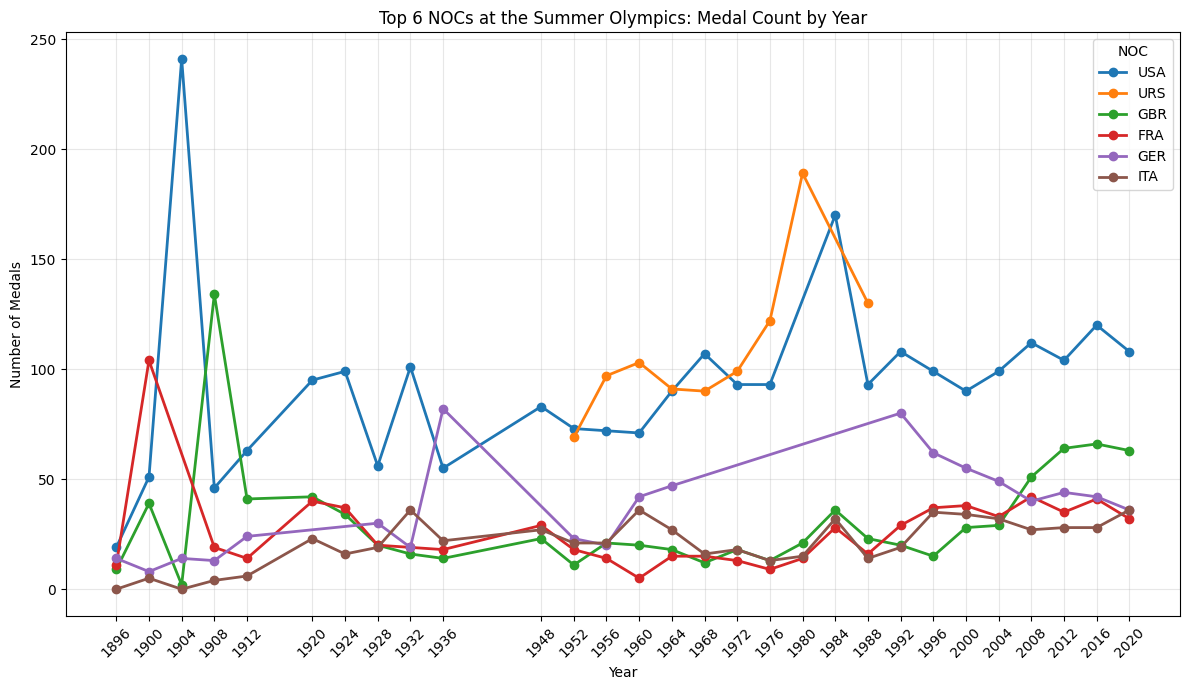

In [54]:
top_nocs = (
    summer_yearly.groupby('noc')['medal_count']
    .sum()
    .nlargest(6)
    .index
)

plt.figure(figsize=(12, 7))

for noc in top_nocs:
    country_data = (
        summer_yearly[summer_yearly['noc'] == noc]
        .sort_values('year')
    )

    plt.plot(
        country_data['year'],
        country_data['medal_count'],
        marker='o',
        linewidth=2,
        label=noc
    )

plt.xlabel('Year')
plt.ylabel('Number of Medals')
plt.title('Top 6 NOCs at the Summer Olympics: Medal Count by Year')
plt.xticks(sorted(summer_yearly['year'].unique()), rotation=45)
plt.legend(title='NOC')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
# Top 10 NOCs by number of medal records
top_10_nocs = (
    medal_events_olympics
    .groupby('noc')
    .size()
    .nlargest(10)
    .index
)

# Medal records by NOC and discipline
discipline_medals = (
    medal_events_olympics[
        medal_events_olympics['noc'].isin(top_10_nocs)
    ]
    .groupby(['noc', 'discipline'])
    .size()
    .reset_index(name='medal_count')
)

# Top 3 disciplines by medals for each NOC
top_disciplines = (
    discipline_medals
    .sort_values(
        ['noc', 'medal_count'],
        ascending=[True, False]
    )
    .groupby('noc')
    .head(3)
    .reset_index(drop=True)
)

top_disciplines

,noc,discipline,medal_count
0,CHN,Diving (Aquatics),81
1,CHN,Artistic Gymnastics (Gymnastics),68
2,CHN,Shooting,66
3,FRA,Fencing,124
4,FRA,Athletics,70
5,FRA,Judo,57
6,GBR,Athletics,215
7,GBR,Swimming (Aquatics),84
8,GBR,Cycling Track (Cycling),76
9,GER,Athletics,117


In [56]:
noc_totals = (
    medal_events_olympics
    .groupby('noc')
    .size()
    .reset_index(name='total_medals')
)

top_disciplines_share = top_disciplines.merge(
    noc_totals,
    on='noc',
    how='left'
)

top_disciplines_share['share_percent'] = (
    top_disciplines_share['medal_count']
    / top_disciplines_share['total_medals'] * 100
).round(2)

top_disciplines_share[
    ['noc', 'discipline', 'medal_count', 'share_percent']
]

,noc,discipline,medal_count,share_percent
0,CHN,Diving (Aquatics),81,12.02
1,CHN,Artistic Gymnastics (Gymnastics),68,10.09
2,CHN,Shooting,66,9.79
3,FRA,Fencing,124,14.04
4,FRA,Athletics,70,7.93
5,FRA,Judo,57,6.46
6,GBR,Athletics,215,22.95
7,GBR,Swimming (Aquatics),84,8.96
8,GBR,Cycling Track (Cycling),76,8.11
9,GER,Athletics,117,11.39


In [57]:
top3_share = (
    top_disciplines_share
    .groupby('noc')
    .agg(
        top3_medals=('medal_count', 'sum'),
        total_medals=('total_medals', 'first')
    )
    .reset_index()
)

top3_share['top3_share_percent'] = (
    top3_share['top3_medals'] / top3_share['total_medals'] * 100
).round(2)

top3_share.sort_values(
    'top3_share_percent',
    ascending=False
)

,noc,top3_medals,total_medals,top3_share_percent
9,USA,1551,2925,53.03
6,NOR,281,560,50.18
5,JPN,276,562,49.11
8,URS,488,1181,41.32
2,GBR,375,937,40.02
7,SWE,252,651,38.71
4,ITA,243,748,32.49
0,CHN,215,674,31.90
1,FRA,251,883,28.43
3,GER,257,1027,25.02


In [58]:
summer_medal_trends = medal_events_olympics[
    medal_events_olympics['season'].eq('Summer')
].copy()

summer_medal_trends['period'] = (
    summer_medal_trends['year'] // 20 * 20
)

period_medals = (
    summer_medal_trends
    .groupby(['noc', 'period'])
    .size()
    .reset_index(name='medal_count')
)

period_medals

,noc,period,medal_count
0,AFG,2000,2
1,AHO,1980,1
2,ALG,1980,7
3,ALG,2000,10
4,ANZ,1900,12
...,...,...,...
508,YUG,1960,28
509,YUG,1980,39
510,ZAM,1980,2
511,ZIM,1980,1


In [59]:
summer_participation = participation[
    participation['season'].eq('Summer')
].copy()

summer_participation['period'] = (
    summer_participation['year'] // 20 * 20
)

period_participation = (
    summer_participation
    .groupby(['noc', 'period'])['games']
    .nunique()
    .reset_index(name='appearances_in_period')
)

period_analysis = period_participation.merge(
    period_medals,
    on=['noc', 'period'],
    how='left'
)

period_analysis['medal_count'] = (
    period_analysis['medal_count'].fillna(0)
)

period_analysis['medals_per_appearance'] = (
    period_analysis['medal_count']
    / period_analysis['appearances_in_period']
).round(2)

period_analysis

,noc,period,appearances_in_period,medal_count,medals_per_appearance
0,AFG,1920,1,0.0,0.0
1,AFG,1940,2,0.0,0.0
2,AFG,1960,4,0.0,0.0
3,AFG,1980,3,0.0,0.0
4,AFG,2000,4,2.0,0.5
...,...,...,...,...,...
951,ZIM,1920,1,0.0,0.0
952,ZIM,1960,2,0.0,0.0
953,ZIM,1980,5,1.0,0.2
954,ZIM,2000,5,7.0,1.4


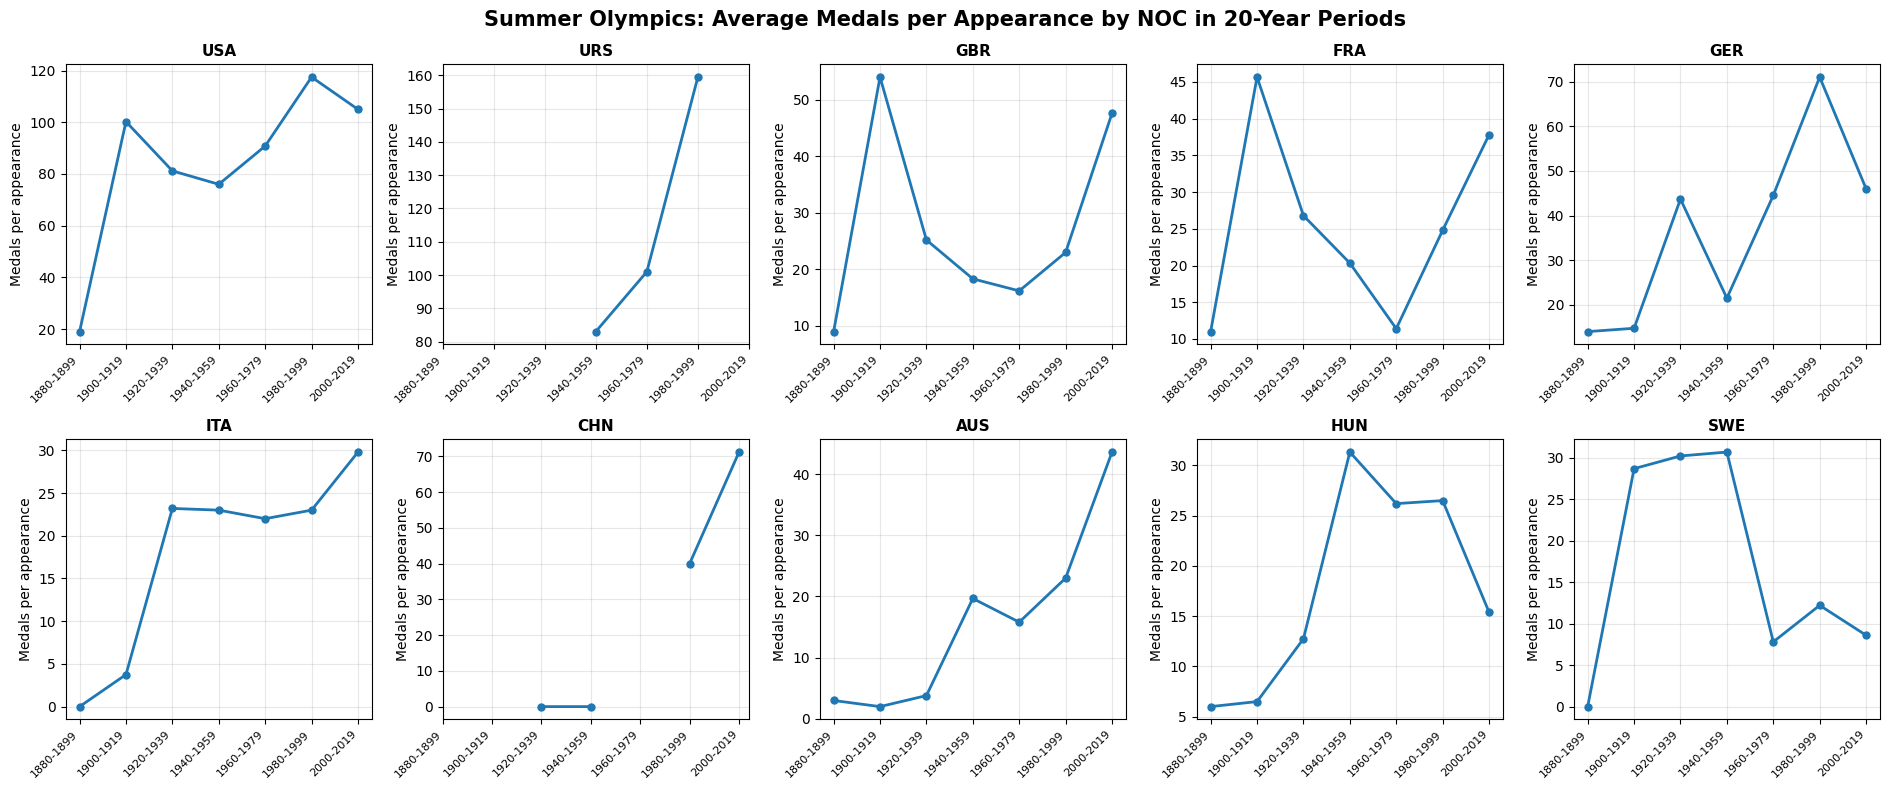

In [60]:
plot_data = period_analysis[
    period_analysis['period'] < 2020
].copy()

top_nocs = (
    plot_data.groupby('noc')['medal_count']
    .sum()
    .nlargest(10)
    .index
)

periods = sorted(plot_data['period'].unique())

period_labels = [
    f'{year}-{year + 19}' for year in periods
]

fig, axes = plt.subplots(2, 5, figsize=(19, 8))
axes = axes.flatten()

for ax, noc in zip(axes, top_nocs):
    country_data = (
        plot_data[plot_data['noc'] == noc]
        .set_index('period')['medals_per_appearance']
        .reindex(periods)
    )

    ax.plot(
        range(len(periods)),
        country_data,
        marker='o',
        linewidth=2,
        markersize=5
    )

    ax.set_title(noc, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(periods)))
    ax.set_xticklabels(
        period_labels,
        rotation=45,
        ha='right',
        fontsize=8
    )
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('Medals per appearance')

fig.suptitle(
    'Summer Olympics: Average Medals per Appearance by NOC in 20-Year Periods',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [61]:
winter_medals = medal_events_olympics[
    medal_events_olympics['season'] == 'Winter'
].copy()

winter_medals['period'] = (
    winter_medals['year'] // 20 * 20
)

winter_period_analysis = (
    winter_medals
    .groupby(['noc', 'period'])
    .size()
    .reset_index(name='medal_count')
)

winter_period_analysis.head()

,noc,period,medal_count
0,AUS,1980,2
1,AUS,2000,13
2,AUS,2020,4
3,AUT,1920,13
4,AUT,1940,27


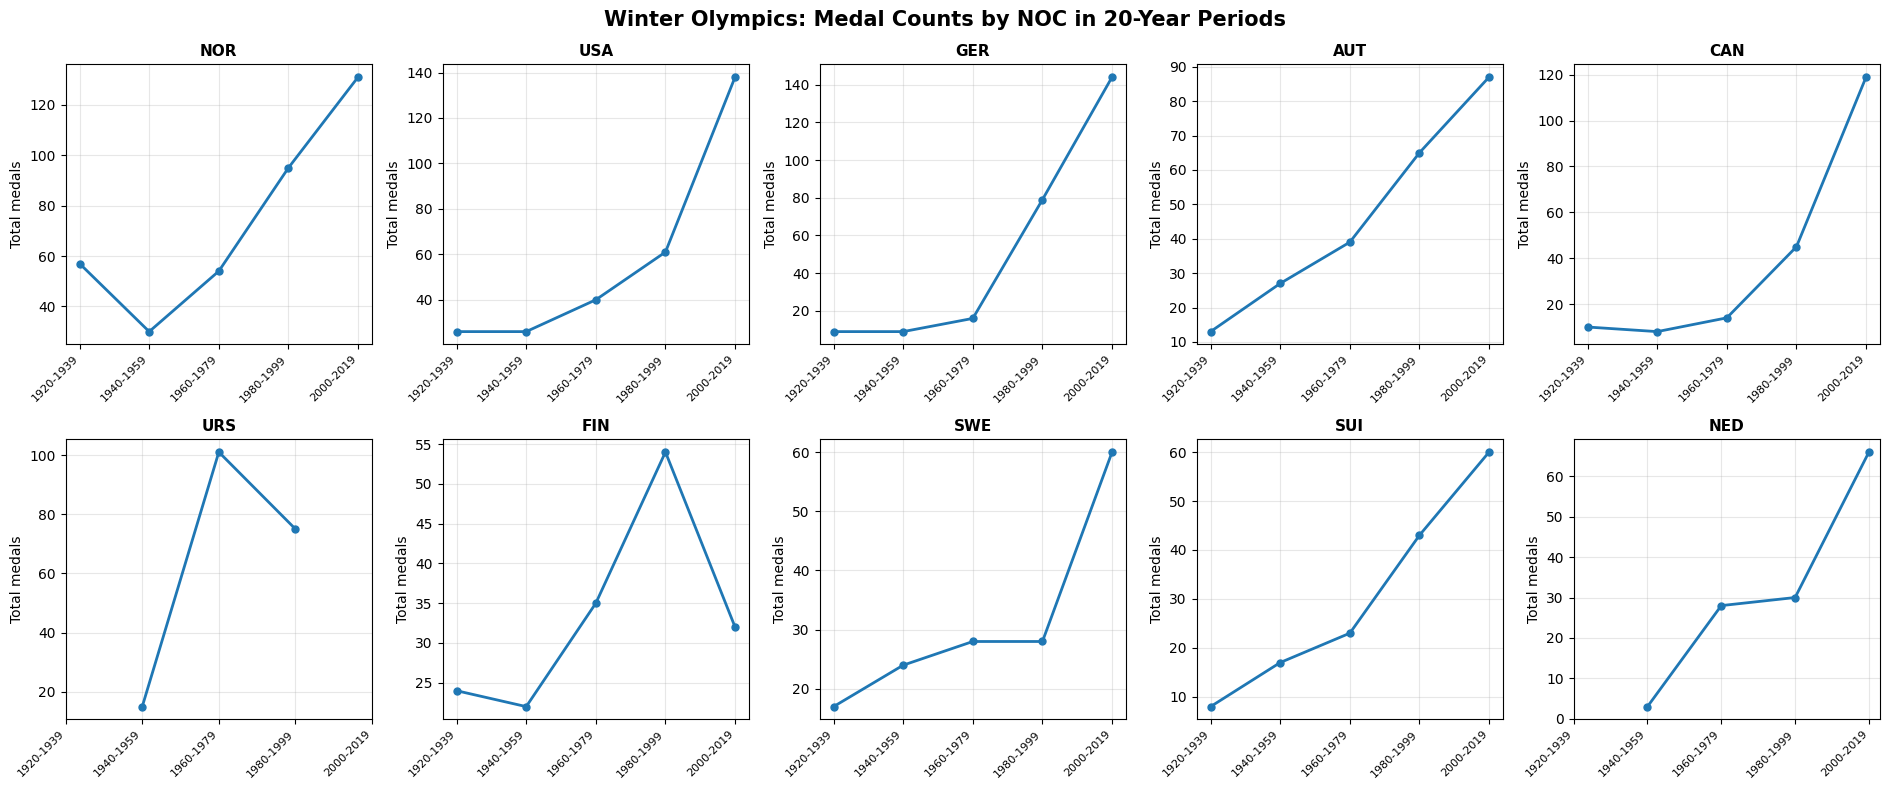

In [62]:
plot_data = winter_period_analysis[
    winter_period_analysis['period'] < 2020
].copy()

top_nocs = (
    plot_data.groupby('noc')['medal_count']
    .sum()
    .nlargest(10)
    .index
)

periods = sorted(plot_data['period'].unique())

period_labels = [
    f'{year}-{year + 19}' for year in periods
]

fig, axes = plt.subplots(2, 5, figsize=(19, 8))
axes = axes.flatten()

for ax, noc in zip(axes, top_nocs):
    country_data = (
        plot_data[plot_data['noc'] == noc]
        .set_index('period')['medal_count']
        .reindex(periods)
    )

    ax.plot(
        range(len(periods)),
        country_data,
        marker='o',
        linewidth=2,
        markersize=5
    )

    ax.set_title(noc, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(periods)))
    ax.set_xticklabels(
        period_labels,
        rotation=45,
        ha='right',
        fontsize=8
    )
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('Total medals')

fig.suptitle(
    'Winter Olympics: Medal Counts by NOC in 20-Year Periods',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [63]:
# Calculate Summer and Winter medal counts per NOC
summer_winter_comparison = (
    medal_events_olympics
    .groupby(['noc', 'season'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['Summer', 'Winter'], fill_value=0)
    .rename(columns={
        'Summer': 'summer_medals',
        'Winter': 'winter_medals'
    })
)

# Total medal count
summer_winter_comparison['total_medals'] = (
    summer_winter_comparison['summer_medals'] +
    summer_winter_comparison['winter_medals']
)

# Sort by total medal count
summer_winter_comparison = (
    summer_winter_comparison
    .sort_values('total_medals', ascending=False)
)

summer_winter_comparison.head(15)

season,summer_medals,winter_medals,total_medals
noc,,,
USA,2611,314,2925
URS,990,191,1181
GER,744,283,1027
GBR,903,34,937
FRA,745,138,883
ITA,610,138,748
CHN,598,76,674
SWE,481,170,651
JPN,487,75,562


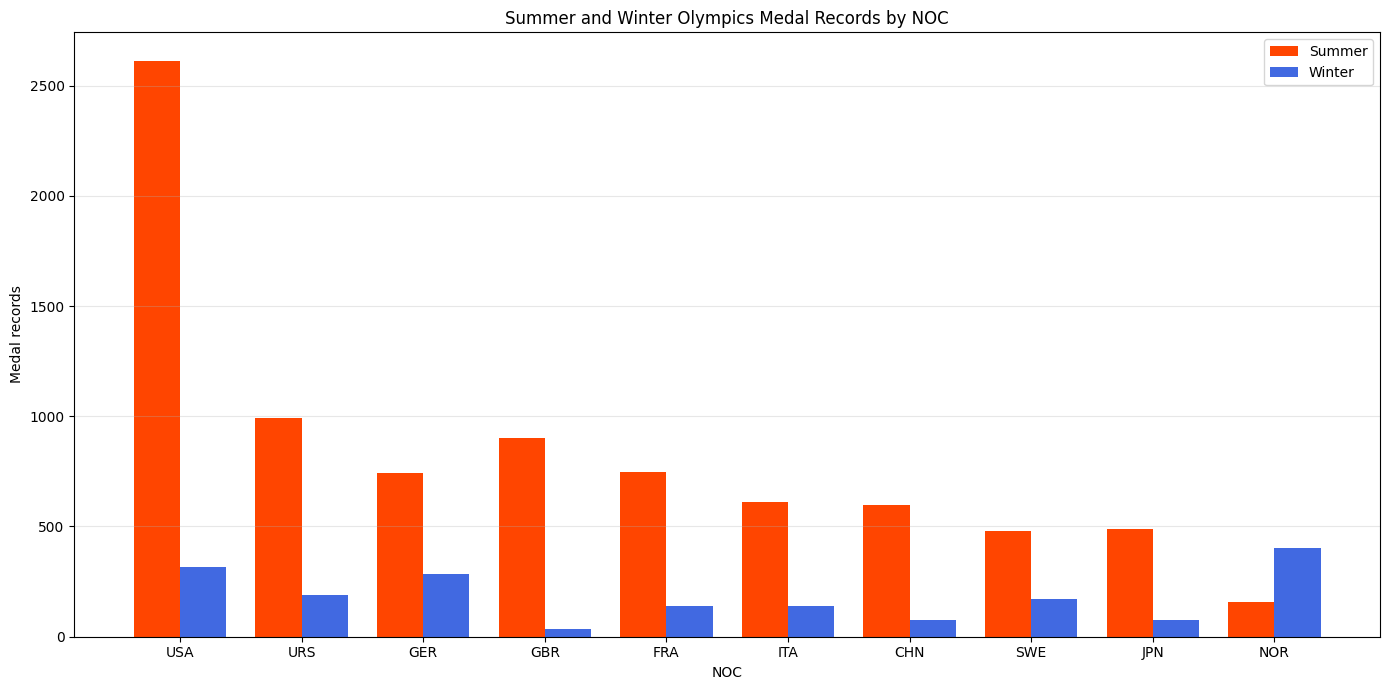

In [64]:
top_nocs = summer_winter_comparison.head(10).index

plot_comparison = summer_winter_comparison.loc[top_nocs]

x = range(len(plot_comparison))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(
    [i - width / 2 for i in x],
    plot_comparison['summer_medals'],
    width,
    label='Summer',
    color= 'orangered'
)

ax.bar(
    [i + width / 2 for i in x],
    plot_comparison['winter_medals'],
    width,
    label='Winter',
    color='royalblue'
)

ax.set_title('Summer and Winter Olympics Medal Records by NOC')
ax.set_xlabel('NOC')
ax.set_ylabel('Medal records')
ax.set_xticks(list(x))
ax.set_xticklabels(top_nocs)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

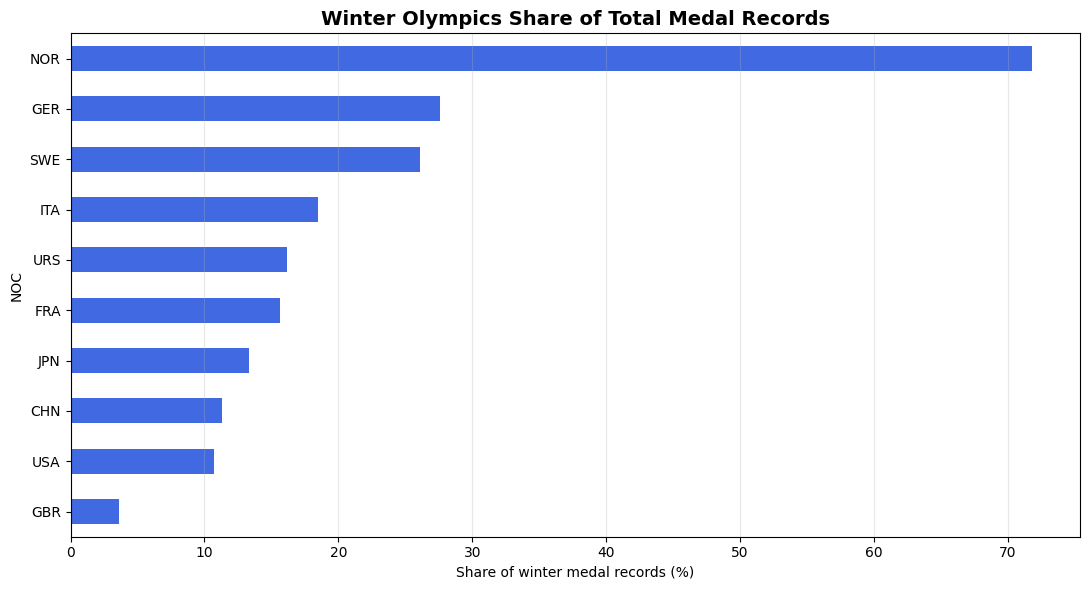

In [65]:
summer_winter_comparison['winter_medal_share'] = (
    summer_winter_comparison['winter_medals']
    / summer_winter_comparison['total_medals'] * 100
)

winter_share_top10 = (
    summer_winter_comparison
    .loc[top_nocs]
    .sort_values('winter_medal_share', ascending=True)
)

ax = winter_share_top10['winter_medal_share'].plot(
    kind='barh',
    figsize=(11, 6),
    color='royalblue'
)

ax.set_title(
    'Winter Olympics Share of Total Medal Records',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Share of winter medal records (%)')
ax.set_ylabel('NOC')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Findings

### Medal Distribution by Country

When the Summer and Winter Olympics are considered together, the USA NOC code has the most medal records. The USA ranks first with 2,925 records, followed by URS with 1,181, GER with 1,027, GBR with 937, and FRA with 883.

These results were obtained without merging historical NOC codes. Therefore, URS, RUS, and other codes were evaluated separately.

### Medal Distribution by Discipline

Countries' medal records are concentrated in certain sports. For the USA, athletics accounts for 825 records, about 28.21% of total medal records, while swimming accounts for 585 records, or 20%.

For NOR, the most records are in cross-country skiing with 139, while for JPN, artistic gymnastics stands out with 99 records. These results show that countries' medal distributions across different sports differ from one another.

### Summer vs. Winter Olympics Comparison

Comparing countries' summer and winter medal records reveals different distributions. The USA earned 2,611 records at the Summer Olympics and 314 at the Winter Olympics. NOR, in contrast, shows a different distribution, with 158 at the Summer Olympics and 402 at the Winter Olympics.

The share of winter medals in total medal records is approximately 71.79% for NOR. For GER this ratio is calculated at approximately 27.56%, and for SWE at 26.11%.

### Changes Over Time

The analyses over 20-year periods show that countries' medal performance varies over time. The Summer Olympics chart examines average medals per appearance, while the Winter Olympics chart examines total medal records.

Because the number of Games editions, participating NOCs, and the competition program can change between periods, the period-based results should not be interpreted as a direct, unconditional comparison of success.
